| título | projeto | versão | data | autores | status |
| :--- | :--- | :--- | :--- | :--- | :--- |
| CRISP-DM — Fase 4: Modeling | Projeção da Taxa de Congestionamento — Justiça Estadual (GO) | 1.0 | 14-12-2025 | Júlio César e Lays de Freitas | Rascunho |


Esse Notebook contém a *Modelagem Preditiva (Baseline)*.

### BIBLIOTECAS

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from dateutil.relativedelta import relativedelta


### IMPORTAÇÃO E CONFIGURAÇÃO

In [11]:
# Carregamento dos dados processados na fase anterior
# Nota: Concatenamos treino e teste para refazer a divisão de forma TEMPORAL (passado vs futuro)

# Configurações visuais
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

try:
    df_train = pd.read_csv('datasets/train-processed.csv')
    df_test_split = pd.read_csv('datasets/test_split.csv')
    df_full = pd.concat([df_train, df_test_split], ignore_index=True)
except FileNotFoundError:
    # Caso não encontre os arquivos, usamos um dataframe simulado baseado na estrutura conhecida
    print("Arquivos não encontrados. Certifique-se de que a Fase 3 foi executada.")

# Garantir que a coluna de data é datetime
df_full['mes_ref'] = pd.to_datetime(df_full['mes_ref'])

# Ordenar por unidade e data
df_full = df_full.sort_values(by=['comarca', 'serventia', 'mes_ref'])

print(f"Total de registros carregados: {len(df_full)}")
print(f"Período dos dados: de {df_full['mes_ref'].min().date()} até {df_full['mes_ref'].max().date()}")

Total de registros carregados: 571917
Período dos dados: de 2022-01-01 até 2025-10-01


### REFINAMENTO DOS DADOS

In [12]:
# Vamos aplicar as regras de negócio para limpar a base antes do split temporal

# 1. Filtro de Tipo de Unidade: Remover CEJUSCs e Execução Penal (se necessário)
# CEJUSCs costumam ter taxas de 0% ou 100% devido a mutirões
filtro_cejusc = ~df_full['serventia'].str.contains('CEJUSC|CENTRO JUDICIÁRIO', case=False, na=False)

# 2. Filtro de Volume (Tratamento de Zeros/Pequenas Amostras)
# Regra: Unidades com menos de 10 processos movimentados (Pendentes + Baixados) no mês são instáveis
# Se Pendentes=1 e Baixados=0 -> Taxa 100%. Se mês seguinte Pendentes=0 e Baixados=1 -> Taxa 0%.
df_full['volume_total'] = df_full['Pendentes_mes'] + df_full['Baixados_mes']
filtro_volume = df_full['volume_total'] >= 10

# Aplicação dos Filtros
df_refinado = df_full[filtro_cejusc & filtro_volume].copy()

# Estatísticas do Refinamento
total_original = len(df_full)
total_refinado = len(df_refinado)
removidos = total_original - total_refinado

print(f"Registros Originais: {total_original}")
print(f"Registros Após Refinamento: {total_refinado}")
print(f"Registros Removidos (Ruído): {removidos} ({removidos/total_original:.1%} da base)")

Registros Originais: 571917
Registros Após Refinamento: 397662
Registros Removidos (Ruído): 174255 (30.5% da base)


### FEATURE ENGINEERING E DIVISÃO TEMPORAL

In [ ]:
# Para Regressão Linear funcionar com datas, precisamos converter a data para um número (ordinal ou timestamp)
# 1. Criação da Feature Numérica de Tempo
df_refinado['mes_ordinal'] = df_refinado['mes_ref'].apply(lambda x: x.toordinal())

# 2. Definição do Ponto de Corte (Split Temporal)
# Vamos usar os últimos 3 meses disponíveis como validação (Teste) e o resto como Treino
data_maxima = df_refinado['mes_ref'].max()
data_corte = data_maxima - relativedelta(months=3)

print(f"Data de Corte para Validação: {data_corte.date()}")

# Separação
df_treino = df_refinado[df_refinado['mes_ref'] <= data_corte].copy()
df_validacao = df_refinado[df_refinado['mes_ref'] > data_corte].copy()

print(f"Registros de Treino (Histórico): {len(df_treino)}")
print(f"Registros de Validação (Recente): {len(df_validacao)}")

Registros de Treino (Histórico): 318129
Registros de Validação (Recente): 79533


### TREINAMENTO DO MODELO (LOOP POR UNIDADE)

In [14]:
# Iremos iterar por cada serventia, treinar uma regressão linear individual e prever
resultados_validacao = []
modelos_dict = {} # Dicionário para guardar os modelos treinados para uso futuro

# Identificar todas as combinações únicas de Comarca e Serventia
unidades = df_refinado[['comarca', 'serventia']].drop_duplicates()

print(f"Iniciando treinamento para {len(unidades)} unidades jurisdicionais...")

for index, row in unidades.iterrows():
    comarca_atual = row['comarca']
    serventia_atual = row['serventia']
    
    # Filtrar dados da unidade específica
    mask_treino = (df_treino['comarca'] == comarca_atual) & (df_treino['serventia'] == serventia_atual)
    mask_valid = (df_validacao['comarca'] == comarca_atual) & (df_validacao['serventia'] == serventia_atual)
    
    dados_treino = df_treino[mask_treino]
    dados_valid = df_validacao[mask_valid]
    
    # Regra de negócio: Precisamos de pelo menos 2 pontos para traçar uma reta
    if len(dados_treino) >= 2:
        # Preparar X e y
        X_train = dados_treino[['mes_ordinal']]
        y_train = dados_treino['Taxa de Congestionamento_mes (%)']
        
        # Instanciar e Treinar
        modelo = LinearRegression()
        modelo.fit(X_train, y_train)
        
        # Guardar modelo
        modelos_dict[(comarca_atual, serventia_atual)] = modelo
        
        # Se houver dados de validação, fazer a previsão para avaliar performance
        if len(dados_valid) > 0:
            X_valid = dados_valid[['mes_ordinal']]
            y_real = dados_valid['Taxa de Congestionamento_mes (%)']
            
            # Previsão
            y_pred = modelo.predict(X_valid)
            
            # Armazenar resultados para avaliação
            temp_df = dados_valid.copy()
            temp_df['Taxa_Prevista'] = y_pred
            # Clipar previsões entre 0 e 100 (pois é taxa %)
            temp_df['Taxa_Prevista'] = temp_df['Taxa_Prevista'].clip(0, 100)
            
            resultados_validacao.append(temp_df)

# Consolidar resultados de validação
df_avaliado = pd.concat(resultados_validacao, ignore_index=True)
print("Treinamento e Validação concluídos.")

Iniciando treinamento para 513 unidades jurisdicionais...
Treinamento e Validação concluídos.


### GERAÇÃO DE PREVISÕES FUTURAS

In [15]:
# Agora vamos projetar 3 meses à frente da data máxima dos dados
previsoes_futuras = []

# Gerar as datas futuras
datas_futuras = [data_maxima + relativedelta(months=i) for i in range(1, 4)]
ordinais_futuros = np.array([d.toordinal() for d in datas_futuras]).reshape(-1, 1)

for (comarca, serventia), modelo in modelos_dict.items():
    # Prever
    preds = modelo.predict(ordinais_futuros)
    
    for data, pred in zip(datas_futuras, preds):
        # Regra de negócio: Taxa não pode ser menor que 0 nem maior que 100
        pred_ajustado = max(0, min(100, pred))
        
        previsoes_futuras.append({
            'comarca': comarca,
            'serventia': serventia,
            'data_futura': data,
            'taxa_prevista': round(pred_ajustado, 2)
        })

df_futuro = pd.DataFrame(previsoes_futuras)
print("Amostra das previsões futuras:")
display(df_futuro.head())

Amostra das previsões futuras:


c:\Users\User\Documents\GitHub\TJGO_AprendizadoDeMaquina\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\User\Documents\GitHub\TJGO_AprendizadoDeMaquina\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\User\Documents\GitHub\TJGO_AprendizadoDeMaquina\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\User\Documents\GitHub\TJGO_AprendizadoDeMaquina\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\User\Documents\GitHub\TJGO_AprendizadoDeMaquina\.venv\Lib\s

,comarca,serventia,data_futura,taxa_prevista
0,ABADIÂNIA,Vara Judicial,2025-11-01,93.90
1,ABADIÂNIA,Vara Judicial,2025-12-01,94.30
2,ABADIÂNIA,Vara Judicial,2026-01-01,94.71
3,ACREÚNA,"1ª Vara Judicial (Família e Sucessões, Infânci...",2025-11-01,94.62
4,ACREÚNA,"1ª Vara Judicial (Família e Sucessões, Infânci...",2025-12-01,95.50


In [16]:
df_futuro.sample(50)

,comarca,serventia,data_futura,taxa_prevista
875,JUSSARA,"2ª Vara Judicial (Fazendas Públicas, Criminal,...",2026-01-01,92.12
1325,TRIBUNAL DE JUSTIÇA,GABINETE DES. JOSÉ PROTO DE OLIVEIRA,2026-01-01,46.48
153,APARECIDA DE GOIÂNIA,6ª Vara Cível,2025-11-01,96.02
1081,QUIRINÓPOLIS,"2ª Vara (Cível, das Faz. Púb., de Reg. Púb. e ...",2025-12-01,96.55
738,GUAPÓ,"1ª Vara Judicial (Família e Sucessões, Infânci...",2025-11-01,94.87
741,GUAPÓ,"2ª Vara Judicial (Fazendas Públicas, Criminal,...",2025-11-01,96.54
716,GOIÂNIA,Central Estadual de Conciliação Pré-Processual,2026-01-01,0.00
1484,URUAÇU,Juizado Especial Cível e Criminal,2026-01-01,100.00
628,GOIÂNIA,4ª Vara de Família,2025-12-01,92.78
1347,TRIBUNAL DE JUSTIÇA,GABINETE DES. PAULO CÉSAR ALVES DAS NEVES,2025-11-01,52.31


In [18]:
# Célula 6 [Code] - Avaliação de Métricas (Evaluation)
# Vamos calcular o erro do nosso modelo nos dados de teste (validação)

mae = mean_absolute_error(df_avaliado['Taxa de Congestionamento_mes (%)'], df_avaliado['Taxa_Prevista'])
rmse = np.sqrt(mean_squared_error(df_avaliado['Taxa de Congestionamento_mes (%)'], df_avaliado['Taxa_Prevista']))

print("=== Performance Global do Modelo (Baseline: Regressão Linear) ===")
print(f"Erro Absoluto Médio (MAE): {mae:.2f} p.p.")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f} p.p.")

# Análise de Erro: Onde o modelo errou mais?
df_avaliado['Erro_Absoluto'] = abs(df_avaliado['Taxa de Congestionamento_mes (%)'] - df_avaliado['Taxa_Prevista'])
top_erros = df_avaliado.sort_values(by='Erro_Absoluto', ascending=False).head(5)

print("\n=== Top 5 Maiores Erros de Previsão ===")
display(top_erros[['comarca', 'serventia', 'mes_ref', 'Taxa de Congestionamento_mes (%)', 'Taxa_Prevista', 'Erro_Absoluto']])

=== Performance Global do Modelo (Baseline: Regressão Linear) ===
Erro Absoluto Médio (MAE): 6.98 p.p.
Raiz do Erro Quadrático Médio (RMSE): 10.13 p.p.

=== Top 5 Maiores Erros de Previsão ===


,comarca,serventia,mes_ref,Taxa de Congestionamento_mes (%),Taxa_Prevista,Erro_Absoluto
35399,GOIÂNIA,3ª Vara da Fazenda Pública Estadual Execução F...,2022-08-01,2.82,93.486836,90.666836
38320,GOIÂNIA,5ª Vara da Fazenda Pública Municipal e de Regi...,2022-12-01,3.64,89.316270,85.676270
73749,TRIBUNAL DE JUSTIÇA,GABINETE DESA. SIRLEI MARTINS DA COSTA,2025-10-01,100.00,18.785212,81.214788
73433,TRIBUNAL DE JUSTIÇA,GABINETE DESA DORACI LAMAR ROSA DA SILVA ANDRADE,2023-07-01,100.00,20.889138,79.110862
78424,ÁGUAS LINDAS DE GOIÁS,"1ª Vara de Fazendas Públicas, Registros Públic...",2024-09-01,14.22,92.962722,78.742722


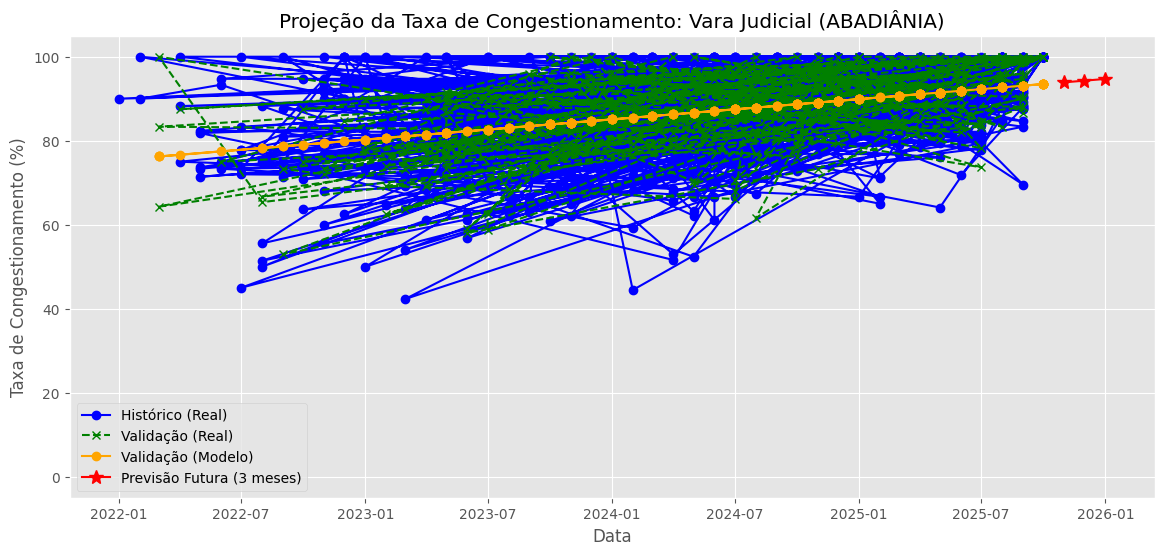

In [19]:
# Célula 7 [Code] - Visualização dos Resultados
# Escolher uma serventia aleatória para plotar: Passado, Validação e Futuro

# Selecionar uma serventia que tenha dados suficientes
amostra = df_treino['serventia'].value_counts().index[0]
comarca_amostra = df_treino[df_treino['serventia'] == amostra]['comarca'].iloc[0]

# Filtrar dados
hist = df_treino[(df_treino['serventia'] == amostra) & (df_treino['comarca'] == comarca_amostra)]
val = df_avaliado[(df_avaliado['serventia'] == amostra) & (df_avaliado['comarca'] == comarca_amostra)]
fut = df_futuro[(df_futuro['serventia'] == amostra) & (df_futuro['comarca'] == comarca_amostra)]

plt.figure(figsize=(14, 6))

# Plotar Histórico (Treino)
plt.plot(hist['mes_ref'], hist['Taxa de Congestionamento_mes (%)'], label='Histórico (Real)', marker='o', color='blue')

# Plotar Validação (Real vs Previsto)
plt.plot(val['mes_ref'], val['Taxa de Congestionamento_mes (%)'], label='Validação (Real)', marker='x', color='green', linestyle='--')
plt.plot(val['mes_ref'], val['Taxa_Prevista'], label='Validação (Modelo)', marker='o', color='orange')

# Plotar Futuro
plt.plot(fut['data_futura'], fut['taxa_prevista'], label='Previsão Futura (3 meses)', marker='*', color='red', markersize=10)

plt.title(f'Projeção da Taxa de Congestionamento: {amostra} ({comarca_amostra})')
plt.ylabel('Taxa de Congestionamento (%)')
plt.xlabel('Data')
plt.legend()
plt.ylim(-5, 105) # Margem para visualização
plt.grid(True)
plt.show()